In [ ]:
# The following project is used to analyze the Netflix Churn and uses the dataset of over a (5000#13) , meaning it is comparitively smaller dataset which is used to predict the best 
#overall model that will help overcome the netflix churn .
# the best models that came soo far is Catboost
# which the model  was overriding in the begining and used the hyperpamateric tuning to overcome all the flaws of the model  and made the model predict the best possible model ,which 
# came out to be the  Catboost with the parameters[depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1]

# CatBoost: ~0.985 max 
# Catboost clearly performs better on unseen data.]
# the best metric = Accuracy
#  the  model learning curves of the RandomForestClassifier and Catboost came out to be pretty close but the main difference between both was the curves ini0tial growth and the pattern of the grapgh 
# growth where the random forest curve grows gradually but the catboost graph is seen with step climp at the start but the overall accuracy of the catboost is better in compare to the random forest 


In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
k=r"C:\Users\YASHVIR\Downloads\netflix_customer_churn.csv"
df=pd.read_csv(k)

In [4]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


In [5]:
df=df.drop(columns=["customer_id"])


In [6]:
df.info(
    
)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   subscription_type       5000 non-null   str    
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 507.9 KB


In [7]:
df.isnull().sum()


age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [8]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [10]:
df.shape

(5000, 13)

In [11]:
df["watch_hours"]=df["watch_hours"].astype("int64")
df["avg_watch_time_per_day"]=df["avg_watch_time_per_day"].astype("int64")
df["monthly_fee"]=df["monthly_fee"].astype("int64")
df["churned"] = df["churned"].astype("int64")



In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["favorite_genre"] = le.fit_transform(df["favorite_genre"])
df["gender"] = le.fit_transform(df["gender"])
df["subscription_type"]=le.fit_transform(df["subscription_type"])
df["payment_method"]=le.fit_transform(df["payment_method"])
df["device"]=le.fit_transform(df["device"])
df["region"]=le.fit_transform(df["region"])

In [13]:
df["gender"].unique()

array([2, 0, 1])

In [14]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)

C:\Users\YASHVIR\AppData\Local\Temp\ipykernel_11840\4193680292.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["gender"].fillna(df["gender"].mode()[0], inplace=True)


0       2
1       2
2       0
3       2
4       2
       ..
4995    0
4996    0
4997    1
4998    0
4999    1
Name: gender, Length: 5000, dtype: int64

In [15]:

df["gender"].unique()

array([2, 0, 1])

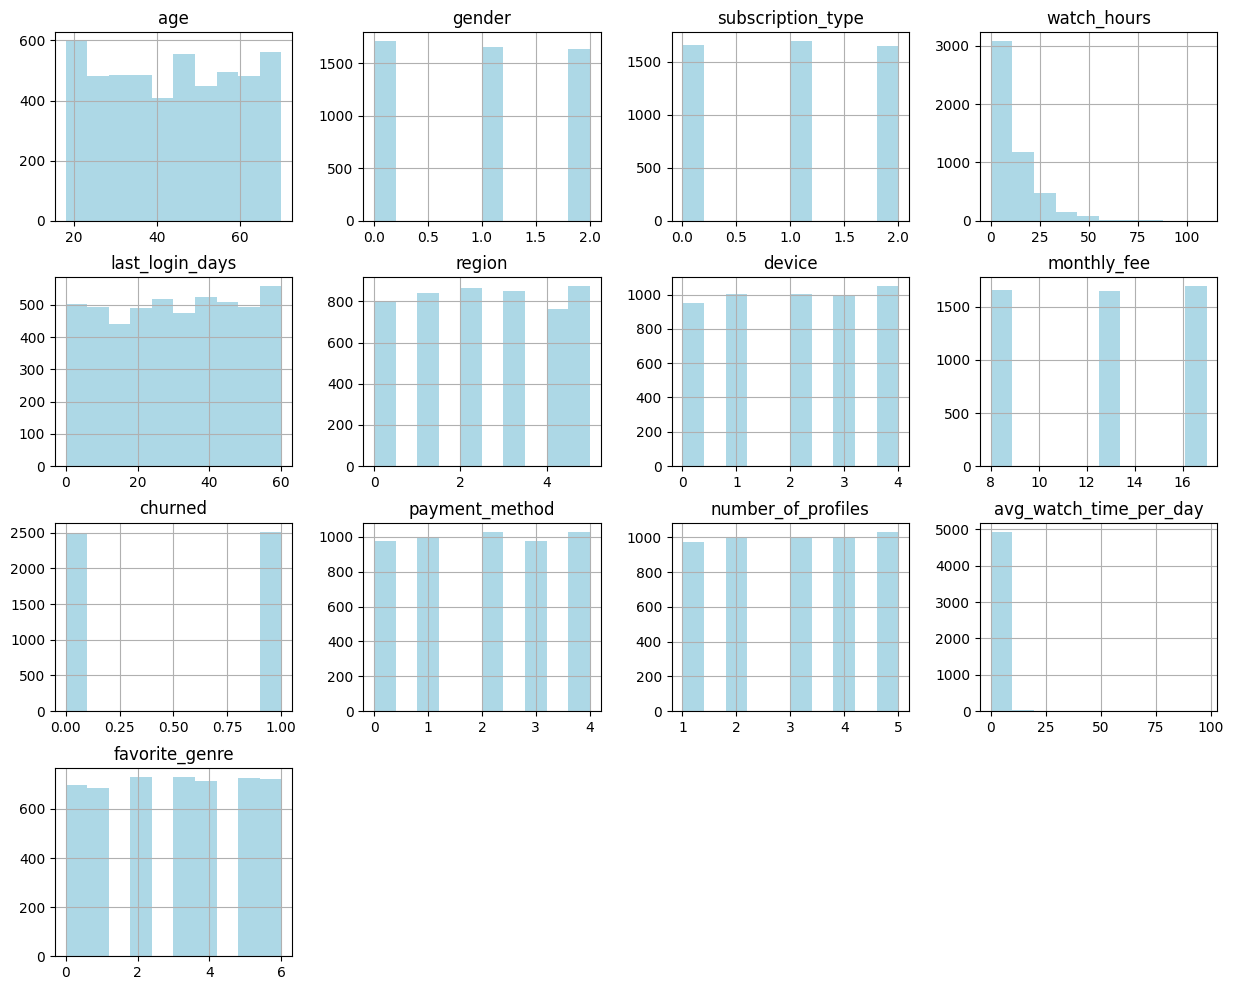

In [16]:
df.hist(figsize=(15,12),color="lightblue")
plt.show()

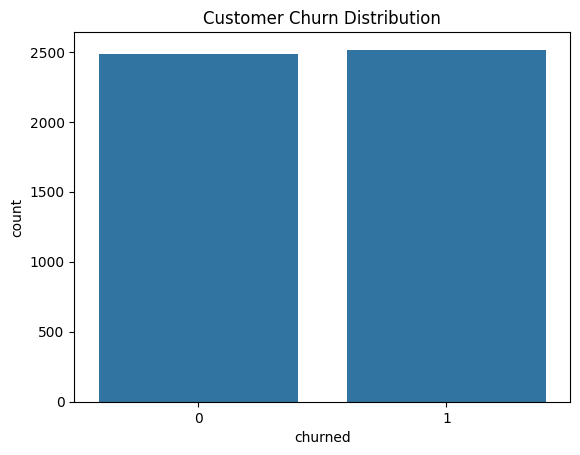

In [17]:
sns.countplot(x="churned", data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [18]:
df["churned"].value_counts()

churned
1    2515
0    2485
Name: count, dtype: int64

In [19]:
X=df.drop(["churned"],axis=1)
y=df["churned"]

In [20]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,f1_score,recall_score,precision_score,accuracy_score,roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
import plotly.express as px
import plotly.express as px
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

In [21]:
X_train,X_test,y_train,y_test=train_test_split (
    X,y,test_size=0.3,random_state=42,stratify=y
)

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train ,y_train)

In [24]:
print(y_train.value_counts())

churned
1    1761
0    1739
Name: count, dtype: int64


In [25]:
print(y_train_smote.value_counts())

churned
1    1761
0    1761
Name: count, dtype: int64


In [26]:
models={
   "logistic regression" :LogisticRegression(max_iter=1000,penalty="l2",solver="liblinear"),
   "xgb_model":XGBClassifier(),
   "lightGBM":LGBMClassifier(),
   "Catboost":CatBoostClassifier(verbose=0),
   "DecisionTreeClassifier":DecisionTreeClassifier(),
   "RandomForestClassifier":RandomForestClassifier(n_estimators=1000),
   "svm_rbf":SVC(kernel="rbf"),
   "svc_linear":SVC(kernel="linear")
   }

In [27]:

results={}
for name, model in  models.items():
  print(f"\nMODEL{name}...")

  model.fit(X_train_scaled,y_train)
  y_pred=model.predict(X_test_scaled)

  accuracy=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred)
  recall =recall_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  if hasattr(model,"predict_proba"):
      y_prob=model.predict_proba(X_test_scaled)[:,1]
  else:
    y_prob=model.decision_function(X_test_scaled)
  roc_auc=roc_auc_score(y_test,y_prob)
  print(f"{name}ROC-AUC Score:{roc_auc:.4f}")
  print(f"{name} Accuracy:{accuracy:.4f}")
  print(f"{name} F1-score:{f1:.4f}")
  print(f"{name} recall:{recall:.4f}")
  print(f"{name}precision:{precision:.4f}")
  print(f"{name} classification report :\n{classification_report(y_test,y_pred)}")
  print(f"{name} Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")
  results[name]={
      'accuracy':accuracy,
      'f1_score':f1,
      'recall':recall,
      "precision":precision,
      "roc_auc":roc_auc,
      'classification_report': classification_report(y_test,y_pred,output_dict=True),
      'confusion_matrix': confusion_matrix(y_test,y_pred).tolist()
  }


MODELlogistic regression...
logistic regressionROC-AUC Score:0.9558
logistic regression Accuracy:0.8800
logistic regression F1-score:0.8819
logistic regression recall:0.8912
logistic regressionprecision:0.8727
logistic regression classification report :
              precision    recall  f1-score   support

           0       0.89      0.87      0.88       746
           1       0.87      0.89      0.88       754

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500

logistic regression Confusion Matrix:
[[648  98]
 [ 82 672]]

MODELxgb_model...
xgb_modelROC-AUC Score:0.9993
xgb_model Accuracy:0.9860
xgb_model F1-score:0.9860
xgb_model recall:0.9814
xgb_modelprecision:0.9906
xgb_model classification report :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       746
           1       0.99      0.98      0.99       754

    accu

C:\Users\YASHVIR\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LightGBM] [Info] Number of positive: 1761, number of negative: 1739
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 247
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503143 -> initscore=0.012572
[LightGBM] [Info] Start training from score 0.012572
lightGBMROC-AUC Score:0.9992
lightGBM Accuracy:0.9860
lightGBM F1-score:0.9860
lightGBM recall:0.9814
lightGBMprecision:0.9906
lightGBM classification report :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       746
           1       0.99      0.98      0.99       754

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg    

C:\Users\YASHVIR\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\YASHVIR\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CatboostROC-AUC Score:0.9996
Catboost Accuracy:0.9873
Catboost F1-score:0.9874
Catboost recall:0.9854
Catboostprecision:0.9893
Catboost classification report :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       746
           1       0.99      0.99      0.99       754

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

Catboost Confusion Matrix:
[[738   8]
 [ 11 743]]

MODELDecisionTreeClassifier...
DecisionTreeClassifierROC-AUC Score:0.9693
DecisionTreeClassifier Accuracy:0.9693
DecisionTreeClassifier F1-score:0.9695
DecisionTreeClassifier recall:0.9708
DecisionTreeClassifierprecision:0.9683
DecisionTreeClassifier classification report :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       746
           1       0.97      0.97      0.97       754

    accuracy           

In [28]:
model_results=pd.DataFrame(results)
model_results

,logistic regression,xgb_model,lightGBM,Catboost,DecisionTreeClassifier,RandomForestClassifier,svm_rbf,svc_linear
accuracy,0.88,0.986,0.986,0.987333,0.969333,0.971333,0.882667,0.878667
f1_score,0.88189,0.986009,0.986009,0.987375,0.969536,0.971352,0.883905,0.880734
recall,0.891247,0.981432,0.981432,0.985411,0.970822,0.966844,0.888594,0.891247
precision,0.872727,0.990629,0.990629,0.989348,0.968254,0.975904,0.879265,0.870466
roc_auc,0.95583,0.999284,0.999186,0.999588,0.969325,0.996534,0.958921,0.955609
classification_report,"{'0': {'precision': 0.8876712328767123, 'recal...","{'0': {'precision': 0.9814077025232404, 'recal...","{'0': {'precision': 0.9814077025232404, 'recal...","{'0': {'precision': 0.9853137516688919, 'recal...","{'0': {'precision': 0.9704301075268817, 'recal...","{'0': {'precision': 0.9667994687915007, 'recal...","{'0': {'precision': 0.8861788617886179, 'recal...","{'0': {'precision': 0.8873626373626373, 'recal..."
confusion_matrix,"[[648, 98], [82, 672]]","[[739, 7], [14, 740]]","[[739, 7], [14, 740]]","[[738, 8], [11, 743]]","[[722, 24], [22, 732]]","[[728, 18], [25, 729]]","[[654, 92], [84, 670]]","[[646, 100], [82, 672]]"


In [29]:
print(model_results.columns)

Index(['logistic regression', 'xgb_model', 'lightGBM', 'Catboost',
       'DecisionTreeClassifier', 'RandomForestClassifier', 'svm_rbf',
       'svc_linear'],
      dtype='str')


In [30]:
print(model_results)

                                                     logistic regression  \
accuracy                                                            0.88   
f1_score                                                         0.88189   
recall                                                          0.891247   
precision                                                       0.872727   
roc_auc                                                          0.95583   
classification_report  {'0': {'precision': 0.8876712328767123, 'recal...   
confusion_matrix                                  [[648, 98], [82, 672]]   

                                                               xgb_model  \
accuracy                                                           0.986   
f1_score                                                        0.986009   
recall                                                          0.981432   
precision                                                       0.990629   
roc_auc    

In [31]:
results_sorted=sorted(results,key=lambda x:x[1],reverse=True)
print(results_sorted)

# this is the code to understand the best algo out of all the algorithms and its in decending order  

['svm_rbf', 'svc_linear', 'logistic regression', 'lightGBM', 'xgb_model', 'DecisionTreeClassifier', 'Catboost', 'RandomForestClassifier']


In [32]:
#  hyperpameter tuning 
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import  StratifiedKFold, RandomizedSearchCV

In [33]:
#  the code above clear;y shows us that the best model to be used is RandomForestClassifier and Catboost
#  and now i'm going to perform hyperparameter tuning over these both models 
rf_params={
    'n_estimators':[100,200],
    'max_depth':[5,10,None]

}

rf_grid=GridSearchCV(RandomForestClassifier(),rf_params,cv=3)
rf_grid.fit(X_train_scaled,y_train)
print("Best RF_Params:",rf_grid.best_params_)

Best RF_Params: {'max_depth': None, 'n_estimators': 200}


In [34]:
model=CatBoostClassifier(verbose=0,early_stopping_rounds=30)
cat_params= {
    "iterations":[100,200,],
    "depth":[4,6],
    "learning_rate":[0.05,0.1,],
    "l2_leaf_reg":[3,5]

}
cat_grid=GridSearchCV(model,cat_params,cv=3)
cat_grid.fit(X_train_scaled,y_train)
print("Best cat_Params:",cat_grid.best_params_)
result=model.randomized_search(
    cat_params,
    X=X_train_scaled,
    y=y_train,
    cv=3,
    partition_random_seed=42,
    plot=False

)
print("best params:",result["params"])

Best cat_Params: {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

bestTest = 0.1228450397
bestIteration = 99

0:	loss: 0.1228450	best: 0.1228450 (0)	total: 212ms	remaining: 1.9s

bestTest = 0.1201093329
bestIteration = 99

1:	loss: 0.1201093	best: 0.1201093 (1)	total: 402ms	remaining: 1.61s

bestTest = 0.07902994863
bestIteration = 199

2:	loss: 0.0790299	best: 0.0790299 (2)	total: 961ms	remaining: 2.24s

bestTest = 0.04915327596
bestIteration = 199

3:	loss: 0.0491533	best: 0.0491533 (3)	total: 1.45s	remaining: 2.17s

bestTest = 0.05119171807
bestIteration = 199

4:	loss: 0.0511917	best: 0.0491533 (3)	total: 1.92s	remaining: 1.92s

bestTest = 0.08538807744
bestIteration = 99

5:	loss: 0.0853881	best: 0.0491533 (3)	total: 2.15s	remaining: 1.44s

bestTest = 0.09373813043
bestIteration = 99

6:	loss: 0.0937381	best: 0.0491533 (3)	total: 2.44s	remaining: 1.05s

bestTest = 0.0575961858
bestIteration = 99

7:	loss: 0.0575962	best: 0.0491533 (3)	total: 2.67s	remaining

In [35]:
grid=GridSearchCV(
    estimator=model,
    param_grid=cat_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)


In [36]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf = best_rf_model.predict(X_test_scaled)
y_prob_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("\n--- Tuned RandomForestClassifier Performance ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


--- Tuned RandomForestClassifier Performance ---
Accuracy: 0.9727
F1-Score: 0.9728
Recall: 0.9721
Precision: 0.9734
ROC-AUC Score: 0.9963
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       746
           1       0.97      0.97      0.97       754

    accuracy                           0.97      1500
   macro avg       0.97      0.97      0.97      1500
weighted avg       0.97      0.97      0.97      1500

Confusion Matrix:
 [[726  20]
 [ 21 733]]


In [37]:
best_cat_model = cat_grid.best_estimator_

y_pred_cat = best_cat_model.predict(X_test_scaled)
y_prob_cat = best_cat_model.predict_proba(X_test_scaled)[:, 1]

accuracy_cat = accuracy_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
recall_cat = recall_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat)
roc_auc_cat = roc_auc_score(y_test, y_prob_cat)

print("\n--- Catboost  ---")
print(f"Accuracy: {accuracy_cat:.4f}")
print(f"F1-Score: {f1_cat:.4f}")
print(f"Recall: {recall_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"ROC-AUC Score: {roc_auc_cat:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_cat))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))


--- Catboost  ---
Accuracy: 0.9873
F1-Score: 0.9873
Recall: 0.9828
Precision: 0.9920
ROC-AUC Score: 0.9995
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       746
           1       0.99      0.98      0.99       754

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500

Confusion Matrix:
 [[740   6]
 [ 13 741]]


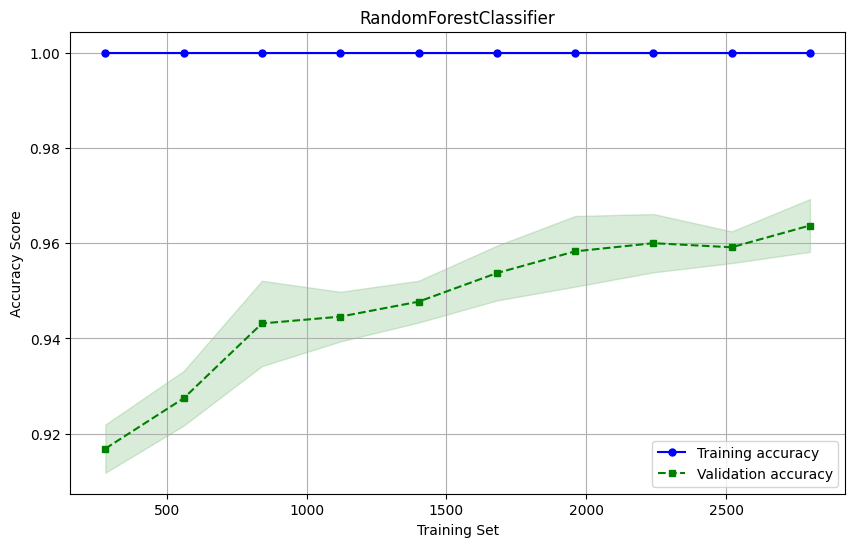

In [38]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_rf_model, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('RandomForestClassifier')
plt.xlabel('Training Set')
plt.ylabel('Accuracy Score')
plt.grid()
plt.legend(loc='lower right')
plt.show()


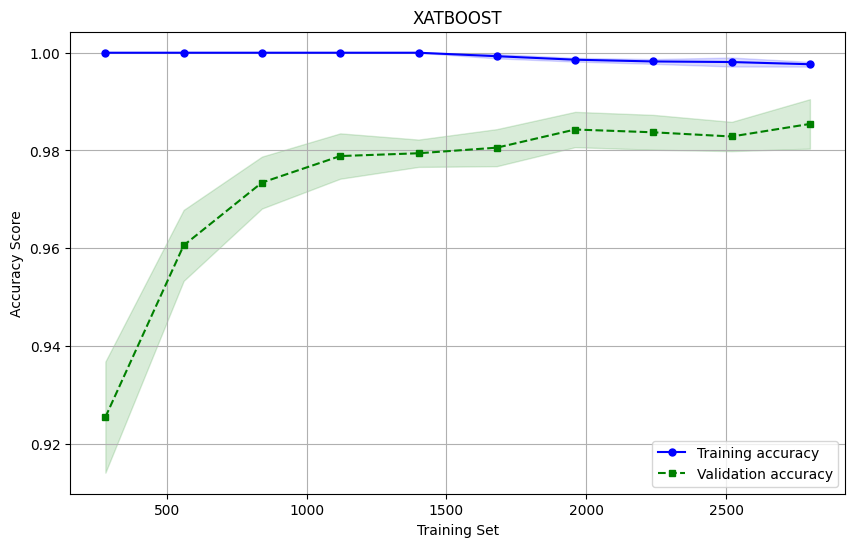

In [39]:
#  Learning curve of the Catboost Algorithm
train_sizes, train_scores, test_scores = learning_curve(
    best_cat_model, X_train_scaled, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy'
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('XATBOOST')
plt.xlabel('Training Set')
plt.ylabel('Accuracy Score')
plt.grid()
plt.legend(loc='lower right')
plt.show()